
# Pandas EDA: Used Car Dataset

This notebook introduces core **pandas** operations for exploratory data analysis (EDA) using a used car dataset.

**What you'll learn:**
- Categorical vs. quantitative variables
- `value_counts()`, sorting, and bar plots
- Column and row selection (`[]`, `.loc`, `.iloc`)
- Selecting multiple columns
- Joint frequency tables (`pd.crosstab`) and grouped bar plots
- Histograms and summary statistics (mean, median, std, IQR, outliers)
- Correlation coefficients (price vs. odometer, price vs. car age)



## 1) Load the dataset

> Place your file `used_cars_train.json` in the working directory.  
> The file should be **line-delimited JSON**, where each line is one car record.

If you don't have the file yet, ask your instructor or adjust `data_path` below to the correct location.


In [ ]:

import json, pandas as pd
from pathlib import Path
from dateutil import parser as dateparser

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 120)

records = []

path = "used_cars_train.json"
f = open(path)

for l in f:
    d = json.loads(l)
    records.append(d)

f.close()

df = pd.DataFrame(records)
df.head(6)


,id,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,size,type,paint_color,state,posting_date
0,7314977535,4000,2007.0,jeep,grand cherokee limited,good,8 cylinders,gas,278000.0,clean,automatic,4wd,mid-size,SUV,silver,or,2021-04-30T12:43:00-0700
1,7314789720,4800,2006.0,chevrolet,silverado,good,8 cylinders,gas,260600.0,clean,automatic,rwd,full-size,pickup,white,fl,2021-04-30T10:31:34-0400
2,7304863686,5500,2007.0,toyota,yaris,excellent,4 cylinders,gas,51000.0,clean,manual,fwd,compact,hatchback,blue,al,2021-04-10T15:11:21-0500
3,7311469964,26990,2016.0,chevrolet,express commercial cutaway,good,8 cylinders,gas,75734.0,clean,automatic,rwd,full-size,truck,white,wi,2021-04-23T13:13:09-0500
4,7305988194,48995,2020.0,toyota,tundra limited 4x4,like new,8 cylinders,gas,20000.0,lien,automatic,4wd,full-size,truck,silver,nm,2021-04-12T20:01:35-0600
5,7315190187,1850,2002.0,volkswagen,jetta gls,good,4 cylinders,gas,240000.0,clean,manual,fwd,mid-size,sedan,black,ca,2021-04-30T23:01:08-0700



## 2) Quick overview


In [ ]:

df.shape, df.dtypes


((71275, 17),
 id                int64
 price             int64
 year            float64
 manufacturer     object
 model            object
 condition        object
 cylinders        object
 fuel             object
 odometer        float64
 title_status     object
 transmission     object
 drive            object
 size             object
 type             object
 paint_color      object
 state            object
 posting_date     object
 dtype: object)

In [ ]:

# Check missingness summary
df.isna().mean().sort_values(ascending=False).head(20)

,0
id,0.0
price,0.0
year,0.0
manufacturer,0.0
model,0.0
condition,0.0
cylinders,0.0
fuel,0.0
odometer,0.0
title_status,0.0



## 3) Categorical vs. Quantitative variables

**Categorical examples:** `manufacturer`, `model`, `fuel`, `transmission`, `drive`, `state`, `type`, `paint_color`, `title_status`  
**Quantitative examples:** `price`, `year`, `odometer`

We'll coerce a couple of columns to categorical dtype for clarity.


In [ ]:

categorical_cols = ["manufacturer", "model", "fuel", "transmission", "drive", "state", "type", "paint_color", "title_status"]
for c in categorical_cols:
    if c in df.columns:
        df[c] = df[c].astype("category")

quant_cols = ["price", "year", "odometer"]
df[categorical_cols + quant_cols].head()


,manufacturer,model,fuel,transmission,drive,state,type,paint_color,title_status,price,year,odometer
0,jeep,grand cherokee limited,gas,automatic,4wd,or,SUV,silver,clean,4000,2007.0,278000.0
1,chevrolet,silverado,gas,automatic,rwd,fl,pickup,white,clean,4800,2006.0,260600.0
2,toyota,yaris,gas,manual,fwd,al,hatchback,blue,clean,5500,2007.0,51000.0
3,chevrolet,express commercial cutaway,gas,automatic,rwd,wi,truck,white,clean,26990,2016.0,75734.0
4,toyota,tundra limited 4x4,gas,automatic,4wd,nm,truck,silver,lien,48995,2020.0,20000.0



## 4) Brand frequencies and bar plots

We'll examine `manufacturer`:
- `value_counts()`
- Sort by **index** (alphabetical) vs. **values** (frequency)
- Bar plots


In [ ]:

brand_counts = df["manufacturer"].value_counts(dropna=True)
brand_counts.head(20)


,count
manufacturer,
ford,13942
chevrolet,10887
toyota,6339
honda,4367
nissan,3576
jeep,2899
gmc,2853
ram,2580
dodge,2271


In [ ]:

# Sort by values (descending default)
brand_counts_sorted_by_value = brand_counts.sort_values(ascending=False)
brand_counts_sorted_by_value.head(20)


,count
manufacturer,
ford,13942
chevrolet,10887
toyota,6339
honda,4367
nissan,3576
jeep,2899
gmc,2853
ram,2580
dodge,2271


In [ ]:

# Sort by index (alphabetical)
brand_counts_sorted_by_index = brand_counts.sort_index()
brand_counts_sorted_by_index.head(20)


,count
manufacturer,
acura,656
alfa-romeo,25
aston-martin,5
audi,840
bmw,1975
buick,931
cadillac,1098
chevrolet,10887
chrysler,1221


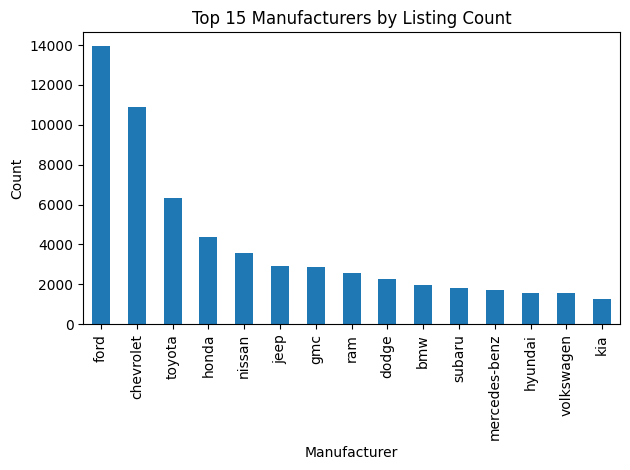

In [ ]:

import matplotlib.pyplot as plt

# Plot by values (top 15)
plt.figure()
brand_counts_sorted_by_value.head(15).plot(kind="bar")
plt.title("Top 15 Manufacturers by Listing Count")
plt.xlabel("Manufacturer")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


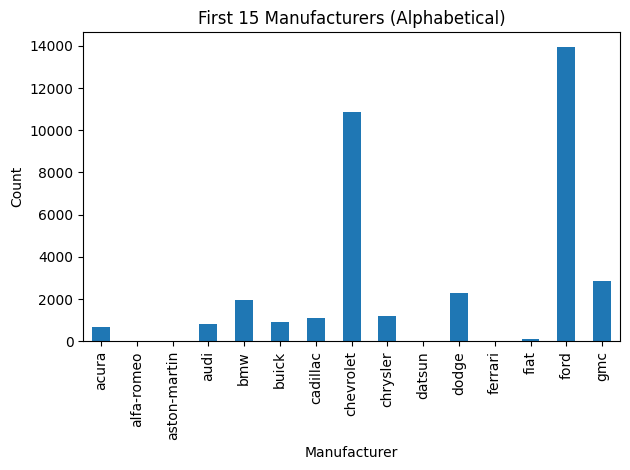

In [ ]:

# Plot by index (alphabetical, top 15 for readability)
plt.figure()
brand_counts_sorted_by_index.head(15).plot(kind="bar")
plt.title("First 15 Manufacturers (Alphabetical)")
plt.xlabel("Manufacturer")
plt.ylabel("Count")
plt.tight_layout()
plt.show()



## 5) Column and row selection

- Single column: `df["price"]` or `df.price`  
- Multiple columns: `df[["manufacturer","model","price"]]`  
- Row selection with boolean filters and `.loc`  
- Positional selection with `.iloc`


In [ ]:

# Single column
df["price"].head()


,price
0,4000
1,4800
2,5500
3,26990
4,48995


In [ ]:

# Multiple columns
df[["manufacturer", "model", "price"]].head()


,manufacturer,model,price
0,jeep,grand cherokee limited,4000
1,chevrolet,silverado,4800
2,toyota,yaris,5500
3,chevrolet,express commercial cutaway,26990
4,toyota,tundra limited 4x4,48995


In [ ]:

# Boolean filter: e.g., gas cars with automatic transmission
mask = (df["fuel"] == "gas") & (df["transmission"] == "automatic")
df.loc[mask, ["manufacturer", "model", "fuel", "transmission", "price"]].head()


,manufacturer,model,fuel,transmission,price
0,jeep,grand cherokee limited,gas,automatic,4000
1,chevrolet,silverado,gas,automatic,4800
3,chevrolet,express commercial cutaway,gas,automatic,26990
4,toyota,tundra limited 4x4,gas,automatic,48995
6,toyota,prius,gas,automatic,5450


In [ ]:

# iloc: first 5 rows, first 5 columns (positional)
df.iloc[-5:, -5:]


,size,type,paint_color,state,posting_date
71270,mid-size,SUV,black,ca,2021-05-04T09:32:31-0700
71271,full-size,pickup,white,ma,2021-05-01T15:09:03-0400
71272,full-size,sedan,custom,ca,2021-04-30T18:18:00-0700
71273,full-size,sedan,grey,oh,2021-04-09T16:18:53-0400
71274,full-size,SUV,blue,fl,2021-04-27T10:35:53-0400



## 6) Joint frequency of categorical variables

Use `pd.crosstab` to compute a contingency table. Example: `manufacturer` vs `fuel`.


In [ ]:

ct_brand_fuel = pd.crosstab(df["manufacturer"], df["fuel"])
ct_brand_fuel.head(10)


fuel,diesel,electric,gas,hybrid,other
manufacturer,,,,,
acura,2,0,654,0,0
alfa-romeo,0,0,25,0,0
aston-martin,0,0,5,0,0
audi,30,0,805,5,0
bmw,28,6,1936,5,0
buick,0,0,931,0,0
cadillac,2,1,1083,9,3
chevrolet,655,18,10148,40,26
chrysler,0,0,1220,1,0


<Figure size 640x480 with 0 Axes>

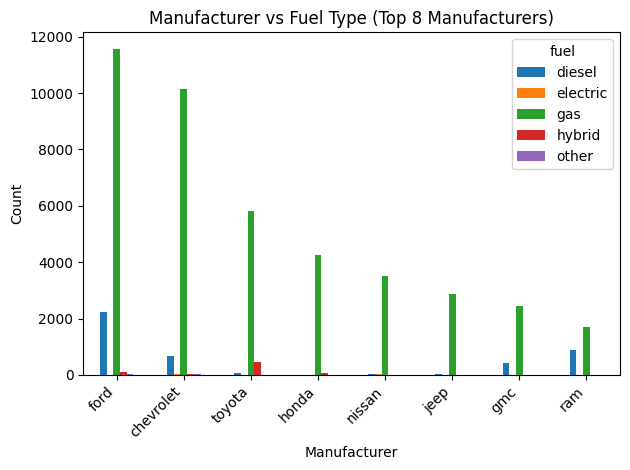

In [ ]:

# Grouped bar plot: brand vs fuel (top 8 brands by volume)
top_brands = brand_counts_sorted_by_value.head(8).index
# print(top_brands)
plt.figure()
ct_brand_fuel.loc[top_brands].plot(kind="bar")
plt.title("Manufacturer vs Fuel Type (Top 8 Manufacturers)")
plt.xlabel("Manufacturer")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()



## 7) Car price histogram


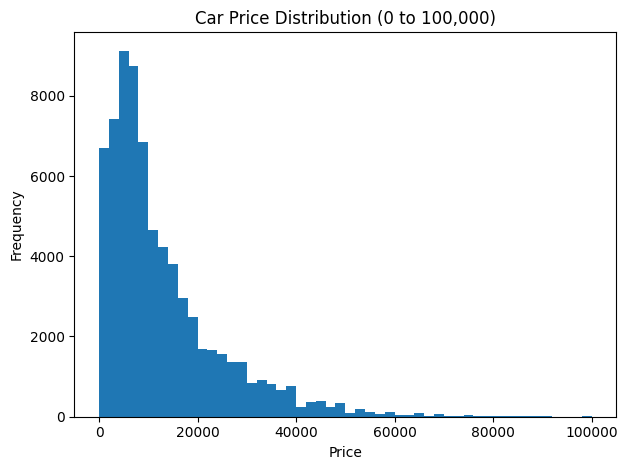

In [ ]:

plt.figure()
df["price"].plot(kind="hist", bins=50, range=(0, 100000))
plt.title("Car Price Distribution (0 to 100,000)")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()




---


## 8) Summary statistics: mean, median, std, IQR, and outliers
We'll use the **1.5×IQR rule** to flag outliers.


In [ ]:

price = df["price"].dropna()

mean_price = price.mean()
median_price = price.median()
std_price = price.std()

Q1 = price.quantile(0.25)
Q3 = price.quantile(0.75)
IQR = Q3 - Q1
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

summary = {
    "mean": mean_price,
    "median": median_price,
    "std": std_price,
    "Q1": Q1,
    "Q3": Q3,
    "IQR": IQR,
    "lower_fence": lower_fence,
    "upper_fence": upper_fence,
    "n_outliers_low": (price < lower_fence).sum(),
    "n_outliers_high": (price > upper_fence).sum(),
}
summary


{'mean': np.float64(86791.19799368642),
 'median': 9000.0,
 'std': 14626370.137375256,
 'Q1': np.float64(4975.0),
 'Q3': np.float64(17500.0),
 'IQR': np.float64(12525.0),
 'lower_fence': np.float64(-13812.5),
 'upper_fence': np.float64(36287.5),
 'n_outliers_low': np.int64(0),
 'n_outliers_high': np.int64(4065)}

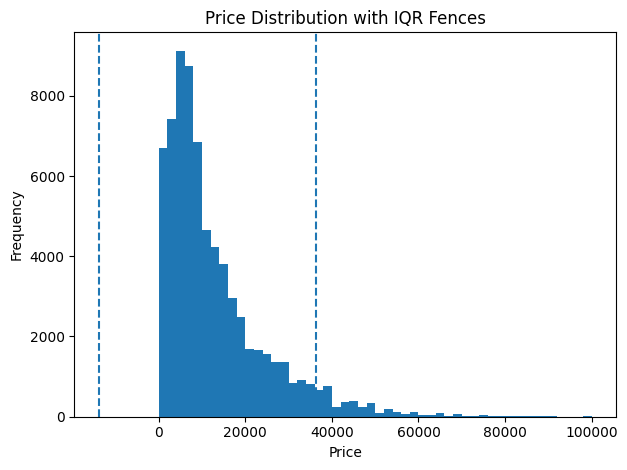

In [ ]:

# Visualize fences on histogram
plt.figure()
price.plot(kind="hist", bins=50, range=(0, 100000))
plt.axvline(lower_fence, linestyle="--")
plt.axvline(upper_fence, linestyle="--")
plt.title("Price Distribution with IQR Fences")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


In [ ]:
filtered_df = df[df['price']<=upper_fence]
print(filtered_df.shape)
filtered_df["price"].mean()

(67210, 17)


np.float64(10977.189867579229)


## 9) Correlation: price vs. odometer


In [ ]:

# Clean numeric columns for correlation
df_corr = df.copy()
for col in ["price", "odometer"]:
    df_corr[col] = pd.to_numeric(df_corr[col], errors="coerce")

corr_price_odo = df_corr[["price","odometer"]].corr(method="pearson").iloc[0,1]
corr_price_odo


np.float64(0.0006632345899587772)


## 10) Scatter Plot: price vs. car age

Compute car age from `posting_date` if available, else from a reference year and the `year` column.


In [ ]:

def compute_age(row):
    y = row.get("year", None)
    pd_date = row.get("posting_date", None)
    if pd.notna(pd_date):
        try:
            post_year = dateparser.parse(pd_date).year
            if pd.notna(y):
                return max(0, post_year - int(y))
        except Exception:
            pass
    # Fallback: assume posting year ~ 2021 if not provided
    try:
        return max(0, 2021 - int(y)) if pd.notna(y) else None
    except Exception:
        return None

df_age = df.copy()
df_age["car_age"] = df_age.apply(compute_age, axis=1)
df_age[["year","posting_date","car_age"]].head()


,year,posting_date,car_age
0,2007.0,2021-04-30T12:43:00-0700,14
1,2006.0,2021-04-30T10:31:34-0400,15
2,2007.0,2021-04-10T15:11:21-0500,14
3,2016.0,2021-04-23T13:13:09-0500,5
4,2020.0,2021-04-12T20:01:35-0600,1


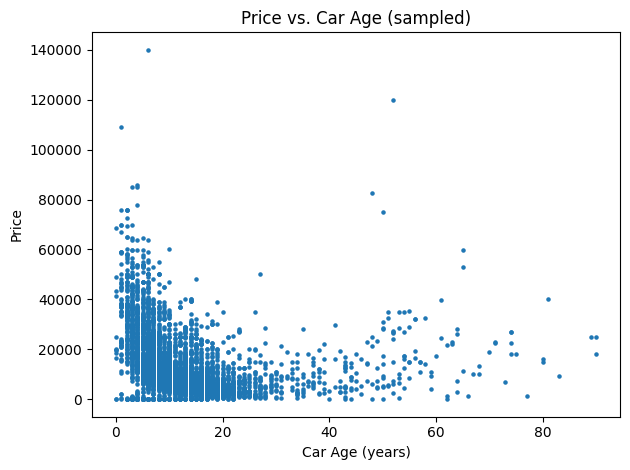

In [ ]:

# Scatter plot (downsample)
sample2 = df_age[["price","car_age"]].dropna().sample(min(5000, len(df_age)), random_state=42)
plt.figure()
plt.scatter(sample2["car_age"], sample2["price"], s=5)
plt.title("Price vs. Car Age (sampled)")
plt.xlabel("Car Age (years)")
plt.ylabel("Price")
plt.tight_layout()
plt.show()


<Axes: title={'center': 'price'}, xlabel='manufacturer'>

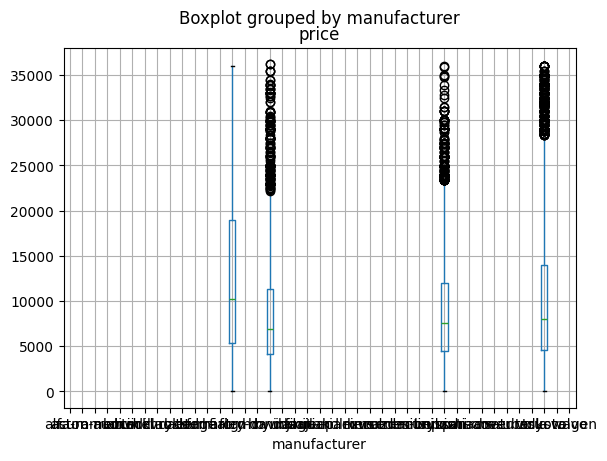

In [ ]:
filtered_df = df[df['price']<= upper_fence]
filtered_df.shape
brand_list = ['toyota', 'honda', 'ford', 'nissan']

filtered_df = filtered_df[filtered_df['manufacturer'].isin(brand_list)]
filtered_df.boxplot("price",by='manufacturer')